# Northwind Traders: Sales Performance and Growth Analysis

## Project Overview

Northwind Traders is a small import/export company that sells specialty foods and beverages to customers across several countries. This project analyzes their historical order data to answer one central question:

**How has Northwind's sales performance changed over time, and what is driving that growth or decline?**

To answer this, the analysis looks at:
- Overall revenue trend over the available time period
- Which products and categories drive the most revenue
- Which customers and countries contribute the most sales
- How individual sales employees are performing

**Data source:** Northwind Traders sample database (orders, order details, products, categories, customers, and employees tables).

**Tools used:** Python (pandas, matplotlib, seaborn) in a Jupyter notebook.

**Scope:** this analysis uses the orders, order details, products, categories, customers, and employees tables. Supplier, shipper, and territory data were intentionally excluded, as they relate to logistics and sourcing questions outside this project's sales performance focus.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## Data Understanding and Cleaning

In [29]:
orders = pd.read_csv("../data/raw/orders.csv")
print(orders.info())
print(orders.isnull().sum())
orders.head()

<class 'pandas.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   orderID         830 non-null    int64  
 1   customerID      830 non-null    str    
 2   employeeID      830 non-null    int64  
 3   orderDate       830 non-null    str    
 4   requiredDate    830 non-null    str    
 5   shippedDate     809 non-null    str    
 6   shipVia         830 non-null    int64  
 7   freight         830 non-null    float64
 8   shipName        830 non-null    str    
 9   shipAddress     830 non-null    str    
 10  shipCity        830 non-null    str    
 11  shipRegion      323 non-null    str    
 12  shipPostalCode  811 non-null    str    
 13  shipCountry     830 non-null    str    
dtypes: float64(1), int64(3), str(10)
memory usage: 90.9 KB
None
orderID             0
customerID          0
employeeID          0
orderDate           0
requiredDate        0
shippedDate

,orderID,customerID,employeeID,orderDate,requiredDate,shippedDate,shipVia,freight,shipName,shipAddress,shipCity,shipRegion,shipPostalCode,shipCountry
0,10248,VINET,5,2024-07-04 00:00:00.000,2024-08-01 00:00:00.000,2024-07-16 00:00:00.000,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
1,10249,TOMSP,6,2024-07-05 00:00:00.000,2024-08-16 00:00:00.000,2024-07-10 00:00:00.000,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany
2,10250,HANAR,4,2024-07-08 00:00:00.000,2024-08-05 00:00:00.000,2024-07-12 00:00:00.000,2,65.83,Hanari Carnes,Rua do Paço 67,Rio de Janeiro,RJ,05454-876,Brazil
3,10251,VICTE,3,2024-07-08 00:00:00.000,2024-08-05 00:00:00.000,2024-07-15 00:00:00.000,1,41.34,Victuailles en stock,2 rue du Commerce,Lyon,NaN,69004,France
4,10252,SUPRD,4,2024-07-09 00:00:00.000,2024-08-06 00:00:00.000,2024-07-11 00:00:00.000,2,51.30,Suprêmes délices,Boulevard Tirou 255,Charleroi,NaN,B-6000,Belgium


In [30]:
order_details = pd.read_csv("../data/raw/order_details.csv")
print(order_details.info())
print(order_details.isnull().sum())
order_details.head()

<class 'pandas.DataFrame'>
RangeIndex: 2155 entries, 0 to 2154
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   orderID    2155 non-null   int64  
 1   productID  2155 non-null   int64  
 2   unitPrice  2155 non-null   float64
 3   quantity   2155 non-null   int64  
 4   discount   2155 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 84.3 KB
None
orderID      0
productID    0
unitPrice    0
quantity     0
discount     0
dtype: int64


,orderID,productID,unitPrice,quantity,discount
0,10248,11,14.0,12,0.0
1,10248,42,9.8,10,0.0
2,10248,72,34.8,5,0.0
3,10249,14,18.6,9,0.0
4,10249,51,42.4,40,0.0


In [31]:
products = pd.read_csv("../data/raw/products.csv")
print(products.info())
print(products.isnull().sum())
products.head()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   productID        77 non-null     int64  
 1   productName      77 non-null     str    
 2   supplierID       77 non-null     int64  
 3   categoryID       77 non-null     int64  
 4   quantityPerUnit  77 non-null     str    
 5   unitPrice        77 non-null     float64
 6   unitsInStock     77 non-null     int64  
 7   unitsOnOrder     77 non-null     int64  
 8   reorderLevel     77 non-null     int64  
 9   discontinued     77 non-null     int64  
dtypes: float64(1), int64(7), str(2)
memory usage: 6.1 KB
None
productID          0
productName        0
supplierID         0
categoryID         0
quantityPerUnit    0
unitPrice          0
unitsInStock       0
unitsOnOrder       0
reorderLevel       0
discontinued       0
dtype: int64


,productID,productName,supplierID,categoryID,quantityPerUnit,unitPrice,unitsInStock,unitsOnOrder,reorderLevel,discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


In [32]:
categories = pd.read_csv("../data/raw/categories.csv")
print(categories.info())
print(categories.isnull().sum())
categories.head()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   categoryID    8 non-null      int64
 1   categoryName  8 non-null      str  
 2   description   8 non-null      str  
 3   picture       8 non-null      str  
dtypes: int64(1), str(3)
memory usage: 388.0 bytes
None
categoryID      0
categoryName    0
description     0
picture         0
dtype: int64


,categoryID,categoryName,description,picture
0,1,Beverages,Soft drinks coffees teas beers and ales,0x151C2F00020000000D000E0014002100FFFFFFFF4269...
1,2,Condiments,Sweet and savory sauces relishes spreads and s...,0x151C2F00020000000D000E0014002100FFFFFFFF4269...
2,3,Confections,Desserts candies and sweet breads,0x151C2F00020000000D000E0014002100FFFFFFFF4269...
3,4,Dairy Products,Cheeses,0x151C2F00020000000D000E0014002100FFFFFFFF4269...
4,5,Grains/Cereals,Breads crackers pasta and cereal,0x151C2F00020000000D000E0014002100FFFFFFFF4269...


In [33]:
customers = pd.read_csv("../data/raw/customers.csv")
print(customers.info())
print(customers.isnull().sum())
customers.head()

<class 'pandas.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   customerID    91 non-null     str  
 1   companyName   91 non-null     str  
 2   contactName   91 non-null     str  
 3   contactTitle  91 non-null     str  
 4   address       91 non-null     str  
 5   city          91 non-null     str  
 6   region        31 non-null     str  
 7   postalCode    90 non-null     str  
 8   country       91 non-null     str  
 9   phone         91 non-null     str  
 10  fax           69 non-null     str  
dtypes: str(11)
memory usage: 7.9 KB
None
customerID       0
companyName      0
contactName      0
contactTitle     0
address          0
city             0
region          60
postalCode       1
country          0
phone            0
fax             22
dtype: int64


,customerID,companyName,contactName,contactTitle,address,city,region,postalCode,country,phone,fax
0,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,NaN,12209,Germany,030-0074321,030-0076545
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,NaN,05021,Mexico,(5) 555-4729,(5) 555-3745
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,NaN,05023,Mexico,(5) 555-3932,NaN
3,AROUT,Around the Horn,Thomas Hardy,Sales Representative,120 Hanover Sq.,London,NaN,WA1 1DP,UK,(171) 555-7788,(171) 555-6750
4,BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Berguvsvägen 8,Luleå,NaN,S-958 22,Sweden,0921-12 34 65,0921-12 34 67


In [34]:
employees = pd.read_csv("../data/raw/employees.csv")
print(employees.info())
print(employees.isnull().sum())
employees.head()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   employeeID       9 non-null      int64  
 1   lastName         9 non-null      str    
 2   firstName        9 non-null      str    
 3   title            9 non-null      str    
 4   titleOfCourtesy  9 non-null      str    
 5   birthDate        9 non-null      str    
 6   hireDate         9 non-null      str    
 7   address          9 non-null      str    
 8   city             9 non-null      str    
 9   region           5 non-null      str    
 10  postalCode       9 non-null      str    
 11  country          9 non-null      str    
 12  homePhone        9 non-null      str    
 13  extension        9 non-null      int64  
 14  photo            9 non-null      str    
 15  notes            9 non-null      str    
 16  reportsTo        8 non-null      float64
 17  photoPath        9 non-null    

,employeeID,lastName,firstName,title,titleOfCourtesy,birthDate,hireDate,address,city,region,postalCode,country,homePhone,extension,photo,notes,reportsTo,photoPath
0,1,Davolio,Nancy,Sales Representative,Ms.,1976-12-08 00:00:00.000,2020-05-01 00:00:00.000,507 20th Ave. E. Apt. 2A,Seattle,WA,98122,USA,(206) 555-9857,5467,0x151C2F00020000000D000E0014002100FFFFFFFF4269...,Education includes a BA in psychology from Col...,2.0,http://accweb/emmployees/davolio.bmp
1,2,Fuller,Andrew,Vice President Sales,Dr.,1980-02-19 00:00:00.000,2020-08-14 00:00:00.000,908 W. Capital Way,Tacoma,WA,98401,USA,(206) 555-9482,3457,0x151C2F00020000000D000E0014002100FFFFFFFF4269...,Andrew received his BTS commercial in 1974 and...,NaN,http://accweb/emmployees/fuller.bmp
2,3,Leverling,Janet,Sales Representative,Ms.,1991-08-30 00:00:00.000,2020-04-01 00:00:00.000,722 Moss Bay Blvd.,Kirkland,WA,98033,USA,(206) 555-3412,3355,0x151C2F00020000000D000E0014002100FFFFFFFF4269...,Janet has a BS degree in chemistry from Boston...,2.0,http://accweb/emmployees/leverling.bmp
3,4,Peacock,Margaret,Sales Representative,Mrs.,1965-09-19 00:00:00.000,2021-05-03 00:00:00.000,4110 Old Redmond Rd.,Redmond,WA,98052,USA,(206) 555-8122,5176,0x151C2F00020000000D000E0014002100FFFFFFFF4269...,Margaret holds a BA in English literature from...,2.0,http://accweb/emmployees/peacock.bmp
4,5,Buchanan,Steven,Sales Manager,Mr.,1983-03-04 00:00:00.000,2021-10-17 00:00:00.000,14 Garrett Hill,London,NaN,SW1 8JR,UK,(71) 555-4848,3453,0x151C2F00020000000D000E0014002100FFFFFFFF4269...,Steven Buchanan graduated from St. Andrews Uni...,2.0,http://accweb/emmployees/buchanan.bmp


### Data Quality Findings

- No duplicate or corrupted records were found in any of the six tables used for this analysis.
- Missing values in `region` fields (orders, customers, employees) are structural, not errors: many countries outside the US/Canada simply do not use a region/state field.
- `shippedDate` is missing for 21 orders, these are orders that had not yet shipped as of the data extract and are excluded from this analysis since shipping timing is outside this project's scope.
- `order_details`, the table used to calculate revenue, is complete with no missing values.
- Several columns present in the raw tables (shipping address details, supplier info, inventory levels, employee personal details) were dropped, as they fall outside the Sales Performance and Growth question this notebook answers.

In [8]:
orders_c = orders[["orderID", "customerID", "employeeID", "orderDate"]].copy()
order_details_c = order_details.copy()
products_c = products[["productID", "productName", "categoryID", "discontinued"]].copy()
categories_c = categories[["categoryID", "categoryName"]].copy()
customers_c = customers[["customerID", "companyName", "country"]].copy()
employees_c = employees[["employeeID", "firstName", "lastName", "title"]].copy()

In [9]:
orders_c["orderDate"] = pd.to_datetime(orders_c["orderDate"])
orders_c.dtypes

orderID                int64
customerID               str
employeeID             int64
orderDate     datetime64[us]
dtype: object

In [10]:
print(orders_c["orderDate"].min(), "to", orders_c["orderDate"].max())

2024-07-04 00:00:00 to 2026-05-06 00:00:00


## Building the Sales Fact Table

To answer questions about revenue, products, customers, and employees together, we merge the six cleaned tables into one row-per-order-line table. Revenue is calculated per line item to account for quantity and discount.

In [11]:
fact = order_details_c.merge(orders_c, on="orderID", how="left")
fact = fact.merge(products_c, on="productID", how="left")
fact = fact.merge(categories_c, on="categoryID", how="left")
fact = fact.merge(customers_c, on="customerID", how="left")
fact = fact.merge(employees_c, on="employeeID", how="left")

fact.shape

(2155, 17)

In [12]:
fact["revenue"] = fact["unitPrice"] * fact["quantity"] * (1 - fact["discount"])
fact[["orderID", "productName", "quantity", "unitPrice", "discount", "revenue"]].head()

,orderID,productName,quantity,unitPrice,discount,revenue
0,10248,Queso Cabrales,12,14.0,0.0,168.0
1,10248,Singaporean Hokkien Fried Mee,10,9.8,0.0,98.0
2,10248,Mozzarella di Giovanni,5,34.8,0.0,174.0
3,10249,Tofu,9,18.6,0.0,167.4
4,10249,Manjimup Dried Apples,40,42.4,0.0,1696.0


In [13]:
print("Missing values per column:")
print(fact.isnull().sum())

print("\nRevenue summary:")
print(fact["revenue"].describe())

print("\nAny negative revenue rows?", (fact["revenue"] < 0).any())
print("Any zero revenue rows?", (fact["revenue"] == 0).sum())

Missing values per column:
orderID         0
productID       0
unitPrice       0
quantity        0
discount        0
customerID      0
employeeID      0
orderDate       0
productName     0
categoryID      0
discontinued    0
categoryName    0
companyName     0
country         0
firstName       0
lastName        0
title           0
revenue         0
dtype: int64

Revenue summary:
count     2155.000000
mean       587.374960
std        969.224235
min          4.800000
25%        147.000000
50%        337.750000
75%        656.000000
max      15810.000000
Name: revenue, dtype: float64

Any negative revenue rows? False
Any zero revenue rows? 0


In [15]:
fact.to_csv("../data/processed/sales_fact_table.csv", index=False)

# Data Analysis

## 1. Monthly Revenue Trend

Is Northwind's revenue growing, shrinking, or flat over time?

In [16]:
monthly_revenue = (
    fact.set_index("orderDate")
    .resample("ME")["revenue"]
    .sum()
    .reset_index()
)
monthly_revenue

,orderDate,revenue
0,2024-07-31,27861.8950
1,2024-08-31,25485.2750
2,2024-09-30,26381.4000
3,2024-10-31,37515.7250
4,2024-11-30,45600.0450
5,2024-12-31,45239.6300
6,2025-01-31,61258.0700
7,2025-02-28,38483.6350
8,2025-03-31,38547.2200
9,2025-04-30,53032.9525


In [17]:
last_full_month = monthly_revenue["orderDate"].iloc[-2]
print("Last complete month:", last_full_month)

monthly_revenue_complete = monthly_revenue[monthly_revenue["orderDate"] <= last_full_month].copy()
monthly_revenue_complete

Last complete month: 2026-04-30 00:00:00


,orderDate,revenue
0,2024-07-31,27861.8950
1,2024-08-31,25485.2750
2,2024-09-30,26381.4000
3,2024-10-31,37515.7250
4,2024-11-30,45600.0450
5,2024-12-31,45239.6300
6,2025-01-31,61258.0700
7,2025-02-28,38483.6350
8,2025-03-31,38547.2200
9,2025-04-30,53032.9525


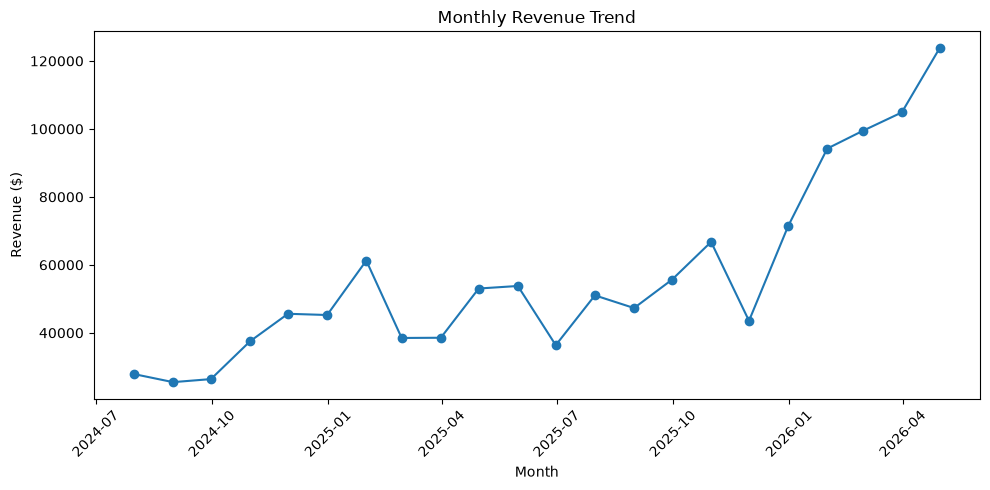

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue_complete["orderDate"], monthly_revenue_complete["revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/monthly_revenue_trend.png", dpi=150)
plt.show()

**Findings:** Revenue shows a clear upward trend across the full history, growing from roughly $27,800 in July 2024 to $123,800 in April 2026, the last complete month in the dataset. The growth is not perfectly smooth, there are month-to-month dips (e.g. June 2025, November 2025), but the overall trajectory is strongly positive, suggesting Northwind's sales are genuinely expanding rather than staying flat. May 2026 is excluded from this chart since the dataset only contains 6 days of that month.

## 2. Top Products and Categories

Which products and categories are driving Northwind's revenue?

In [19]:
product_revenue = (
    fact.groupby("productName")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
product_revenue

,productName,revenue
0,Côte de Blaye,141396.735
1,Thüringer Rostbratwurst,80368.672
2,Raclette Courdavault,71155.700
3,Tarte au sucre,47234.970
4,Camembert Pierrot,46825.480
5,Gnocchi di nonna Alice,42593.060
6,Manjimup Dried Apples,41819.650
7,Alice Mutton,32698.380
8,Carnarvon Tigers,29171.875
9,Rössle Sauerkraut,25696.640


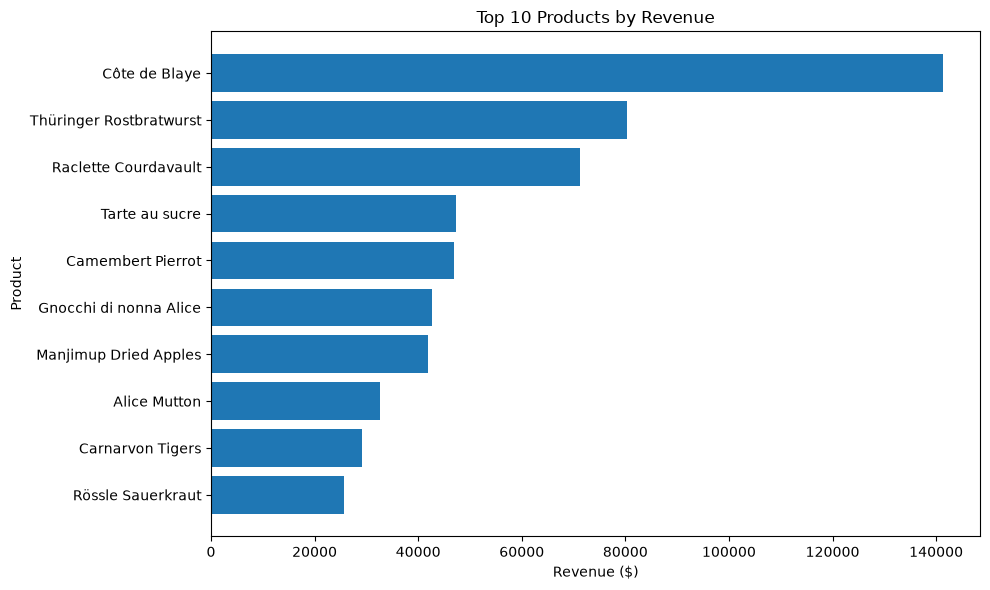

In [20]:
plt.figure(figsize=(10, 6))
plt.barh(product_revenue["productName"], product_revenue["revenue"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/top_10_products.png", dpi=150)
plt.show()

In [21]:
category_revenue = (
    fact.groupby("categoryName")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
category_revenue

,categoryName,revenue
0,Beverages,267868.1800
1,Dairy Products,234507.2850
2,Confections,167357.2250
3,Meat/Poultry,163022.3595
4,Seafood,131261.7375
5,Condiments,106047.0850
6,Produce,99984.5800
7,Grains/Cereals,95744.5875


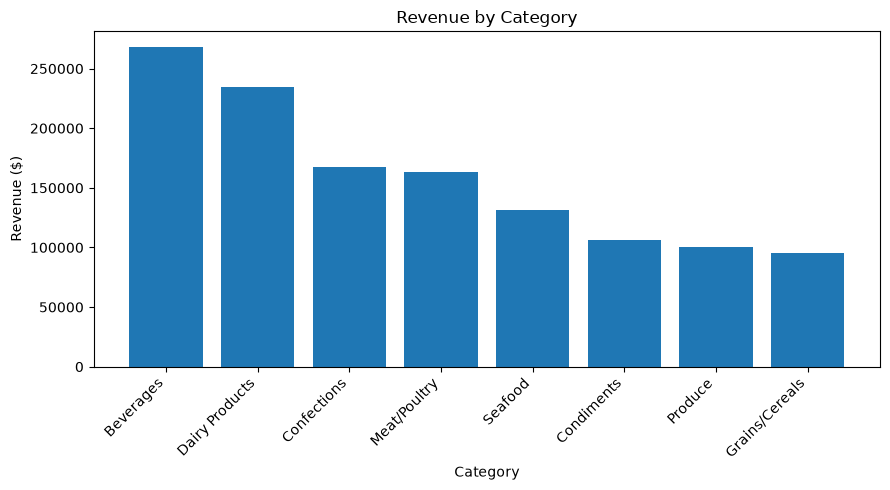

In [22]:
plt.figure(figsize=(9, 5))
plt.bar(category_revenue["categoryName"], category_revenue["revenue"])
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../images/revenue_by_category.png", dpi=150)
plt.show()

**Findings:** Revenue is noticeably concentrated at the product level: Côte de Blaye alone accounts for roughly 11% of total revenue ($141,397), and the top 3 products (Côte de Blaye, Thüringer Rostbratwurst, Raclette Courdavault) together make up about 23% of all revenue, out of 77 products in the catalog. This kind of concentration is a business risk worth flagging, Northwind is meaningfully dependent on a small handful of bestsellers.

At the category level, the picture is more balanced. Beverages leads (about 21% of revenue), closely followed by Dairy Products (about 19%), with the remaining six categories spread fairly evenly down to Grains/Cereals (about 8%). So while no single category dominates, the underlying product mix within those categories is quite top-heavy.

## 3. Top Customers and Countries

Which customers and countries contribute the most to Northwind's revenue?

In [23]:
customer_revenue = (
    fact.groupby("companyName")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
customer_revenue

,companyName,revenue
0,QUICK-Stop,110277.3050
1,Ernst Handel,104874.9785
2,Save-a-lot Markets,104361.9500
3,Rattlesnake Canyon Grocery,51097.8005
4,Hungry Owl All-Night Grocers,49979.9050
5,Hanari Carnes,32841.3700
6,Königlich Essen,30908.3840
7,Folk och fä HB,29567.5625
8,Mère Paillarde,28872.1900
9,White Clover Markets,27363.6050


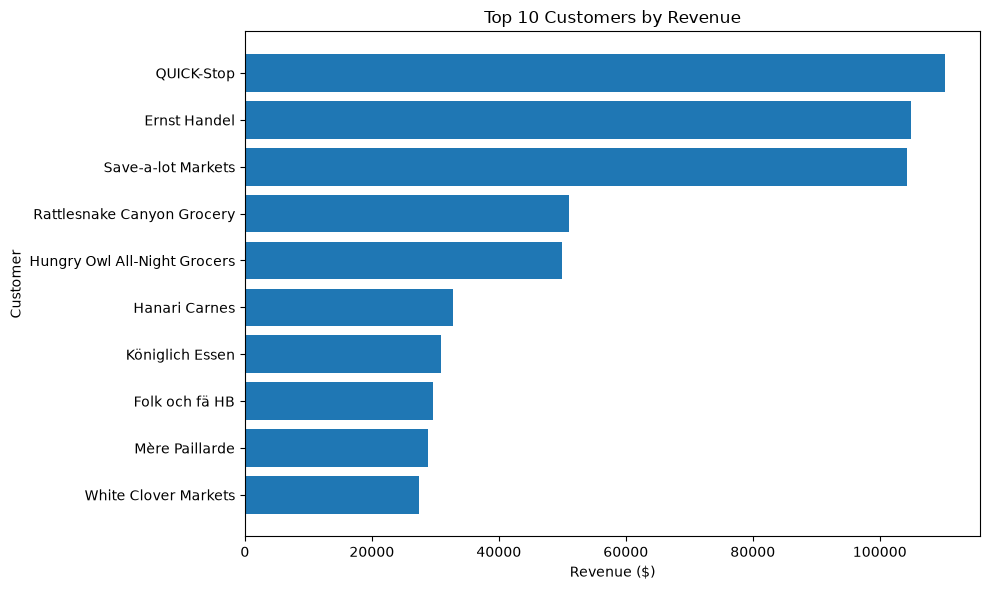

In [25]:
plt.figure(figsize=(10, 6))
plt.barh(customer_revenue["companyName"], customer_revenue["revenue"])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Customer")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/top_10_customers.png", dpi=150)
plt.show()

In [24]:
country_revenue = (
    fact.groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
country_revenue

,country,revenue
0,USA,245584.6105
1,Germany,230284.6335
2,Austria,128003.8385
3,Brazil,106925.7765
4,France,81358.3225
5,UK,58971.3100
6,Venezuela,56810.6290
7,Sweden,54495.1400
8,Canada,50196.2900
9,Ireland,49979.9050


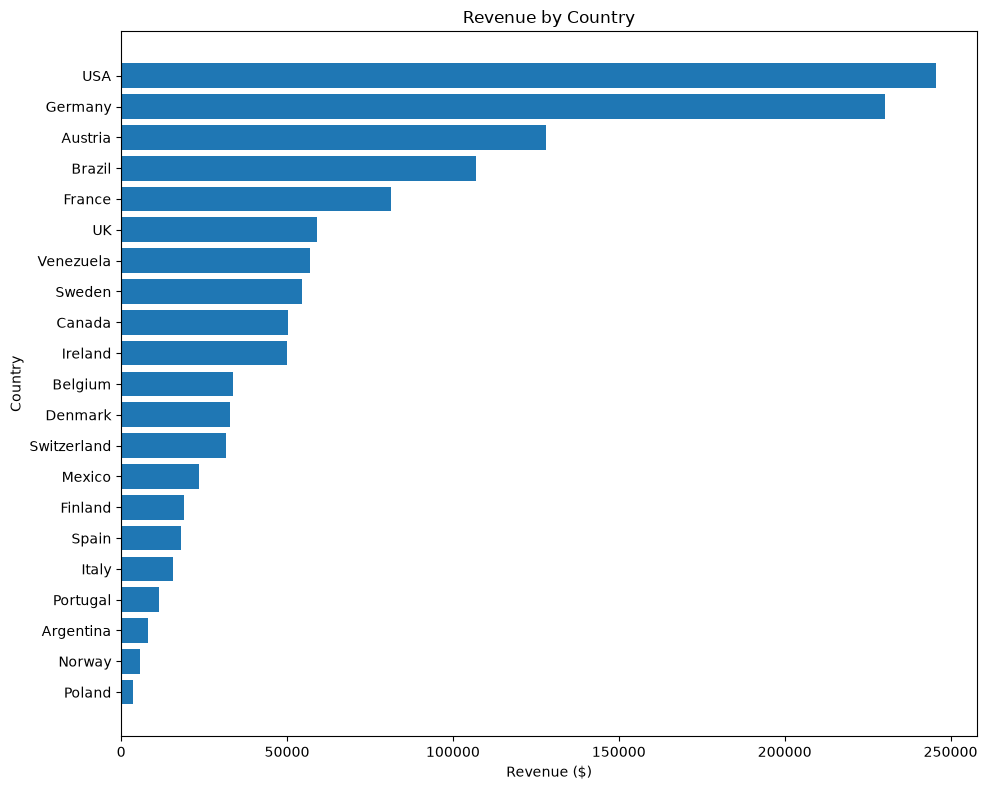

In [26]:
plt.figure(figsize=(10, 8))
plt.barh(country_revenue["country"], country_revenue["revenue"])
plt.title("Revenue by Country")
plt.xlabel("Revenue ($)")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/revenue_by_country.png", dpi=150)
plt.show()

**Findings:** Customer revenue is moderately concentrated: the top 3 customers (QUICK-Stop, Ernst Handel, Save-a-lot Markets) together account for roughly 25% of total revenue, out of 89 customers in total. No single customer dominates the way Côte de Blaye did at the product level, but the top few accounts clearly matter more than average and are worth prioritizing for retention.

Geographically, revenue is more concentrated than the customer count alone would suggest. The USA and Germany are the two largest markets, together contributing over a third of total revenue, and the top 5 countries (USA, Germany, Austria, Brazil, France) account for roughly 63% of revenue across all 21 countries served. This suggests Northwind's growth is currently anchored in a handful of core markets, with a long tail of smaller countries contributing relatively little individually.

## 4. Employee Performance

Which sales employees are driving the most revenue, and how does performance compare across the team?

In [27]:
fact["employeeName"] = fact["firstName"] + " " + fact["lastName"]

employee_perf = (
    fact.groupby("employeeName")
    .agg(
        total_revenue=("revenue", "sum"),
        order_count=("orderID", "nunique"),
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)
employee_perf["avg_order_value"] = employee_perf["total_revenue"] / employee_perf["order_count"]
employee_perf

,employeeName,total_revenue,order_count,avg_order_value
0,Margaret Peacock,232890.8460,156,1492.890038
1,Janet Leverling,202812.8430,127,1596.951520
2,Nancy Davolio,192107.6045,123,1561.850443
3,Andrew Fuller,166537.7550,96,1734.768281
4,Laura Callahan,126862.2775,104,1219.829591
5,Robert King,124568.2350,72,1730.114375
6,Anne Dodsworth,77308.0665,43,1797.862012
7,Michael Suyama,73913.1295,67,1103.181037
8,Steven Buchanan,68792.2825,42,1637.911488


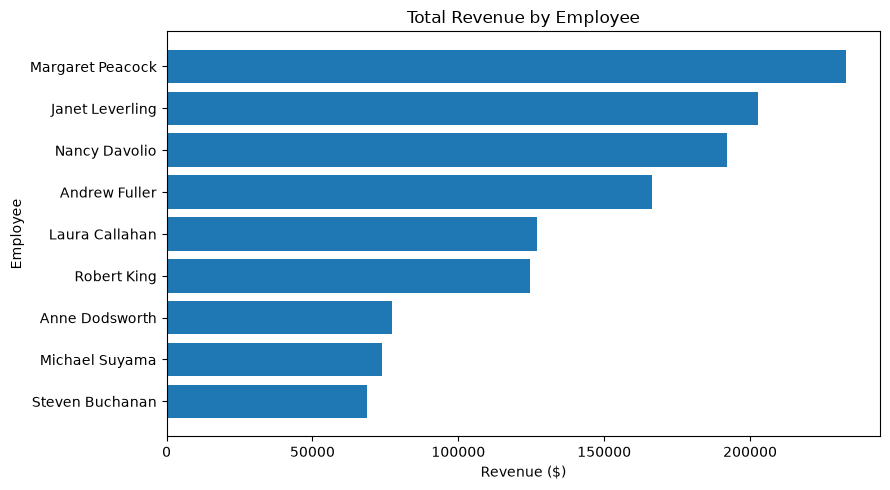

In [28]:
plt.figure(figsize=(9, 5))
plt.barh(employee_perf["employeeName"], employee_perf["total_revenue"])
plt.title("Total Revenue by Employee")
plt.xlabel("Revenue ($)")
plt.ylabel("Employee")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/employee_performance.png", dpi=150)
plt.show()

**Findings:** Margaret Peacock is the top performer by total revenue ($232,891 across 156 orders), with Janet Leverling and Nancy Davolio close behind. For most employees, total revenue tracks closely with order volume, more orders handled generally means more revenue generated.

Average order value tells a different story, however. Anne Dodsworth has the highest average order value ($1,798) despite ranking 7th in total revenue, and Andrew Fuller and Robert King also post strong averages (over $1,730) without leading on total volume. Michael Suyama has the lowest average order value ($1,103) despite a mid-range order count. This suggests two distinct performance patterns on the team: high-volume sellers (like Margaret Peacock) versus high-value-per-deal sellers (like Anne Dodsworth), which may be worth recognizing separately rather than ranking everyone on total revenue alone.

# Conclusions and Recommendations

This analysis examined Northwind's sales performance across roughly two years of order history (July 2024 to April 2026, the last complete month in the data), looking at overall trend, product and category mix, customer and geographic concentration, and employee performance.

**1. Revenue is growing strongly, and the trend should be monitored, not assumed.**
Monthly revenue grew from about $27,800 to $123,800 over the period analyzed, a clearly positive trajectory. Since growth is not perfectly smooth (some months dip), it would be worth tracking this trend on a rolling basis going forward, rather than assuming growth will continue automatically. Recommendation: set up a recurring monthly revenue check against this baseline to catch a slowdown early.

**2. Revenue is concentrated in a small number of products, this is a supply risk.**
The top 3 products account for about 23% of total revenue, with Côte de Blaye alone contributing roughly 11%. Recommendation: ensure supply continuity for these top products specifically (backup suppliers, safety stock), since a disruption to any one of them would have an outsized impact on total revenue.

**3. Revenue is concentrated in a handful of core markets.**
The top 5 countries (USA, Germany, Austria, Brazil, France) generate about 63% of total revenue, while individual customer concentration is more moderate (top 3 customers at about 25%). Recommendation: continue investing in these core markets, but also treat the long tail of smaller countries as an area worth testing for growth, since they currently contribute little individually but represent an unexploited base.

**4. The sales team has two distinct performance patterns worth recognizing separately.**
Some employees (e.g. Margaret Peacock) drive revenue primarily through order volume, while others (e.g. Anne Dodsworth) post a notably higher average order value with fewer orders. Recommendation: evaluate the team on both total revenue and average order value, not total revenue alone, so high-value sellers aren't undervalued relative to high-volume ones.

**Limitations:** this analysis covers sales performance only. Questions around shipping cost, delivery reliability, and inventory risk were intentionally out of scope for this project and would be natural next steps for a follow-up analysis.